# 05 — Naïve Bayes Interpretability

## What This Notebook Covers

While the Decision Tree expresses its knowledge as **rules** (notebook 04), Naïve Bayes expresses it as **probability distributions**. Instead of asking *which questions split the data best?*, it asks: *what does each feature look like for each class, and how well does a new patient's profile match those descriptions?*

### How Gaussian Naïve Bayes Works

Naïve Bayes is grounded in **Bayes' theorem**. To classify a new patient, it estimates the probability of each class given that patient's feature values, then picks the class with the highest result:

```
P(class | features)  ∝  P(features | class) × P(class)
```

The **"naive" assumption** is that all features are *conditionally independent* given the class — knowing a patient's ejection fraction tells the model nothing extra about their serum creatinine. This is medically untrue (the two are clinically coupled), but the simplification often works well in practice.

**Gaussian NB** handles continuous features by fitting a **normal (Gaussian) distribution** to each feature within each class. During training it estimates two parameters per feature per class:

| Parameter | Symbol | Stored in | Meaning |
|---|---|---|---|
| Mean | μ | `model.theta_` | Average value of this feature for patients in this class |
| Variance | σ² | `model.var_` | How spread out the values are around that mean |

Those two matrices — shape `(n_classes, n_features)` each — are the **entire model**. There are no hidden layers, no ensemble weights, no opaque transformations. The model's understanding of the world is fully exposed and directly readable.

At prediction time the model computes how likely each feature value is under each class's Gaussian, multiplies those likelihoods together across all features (the naive independence assumption), applies the class prior, and returns the class with the highest result.

### What We Will Explore

1. **Class Statistics Table** — the learned means and standard deviations per class, ranked by how much they differ between Survived and Deceased
2. **Distribution Plots** — a visual rendering of the two learned Gaussians for every feature, making separation (or lack of it) immediately visible

> For a full plain-English description of each clinical feature and its normal range, refer to the **Feature Glossary in notebook 04**.

In [1]:
import sys
sys.path.insert(0, '..')

from src.data import load_data, split_data
from src.models import train_naive_bayes
from src.interpret_nb import class_statistics, plot_feature_distributions

In [2]:
X, y = load_data('../data/heart_failure_clinical_records_dataset.csv')
X_train, X_test, y_train, y_test = split_data(X, y)

pipeline = train_naive_bayes(X_train, y_train)

# Same label mapping as notebook 04 — no full glossary repeated here
FEATURE_LABELS = {
    'age':                      'Age (years)',
    'anaemia':                  'Anaemia',
    'creatinine_phosphokinase': 'CPK Enzyme Level (µg/L)',
    'diabetes':                 'Diabetes',
    'ejection_fraction':        'Ejection Fraction (%)',
    'high_blood_pressure':      'High Blood Pressure',
    'platelets':                'Platelet Count (kiloplatelets/mL)',
    'serum_creatinine':         'Serum Creatinine (mg/dL)',
    'serum_sodium':             'Serum Sodium (mEq/L)',
    'sex':                      'Sex (0=Female, 1=Male)',
    'smoking':                  'Smoking',
}

FEATURE_NAMES  = list(X.columns)
READABLE_NAMES = [FEATURE_LABELS[f] for f in FEATURE_NAMES]
CLASS_NAMES    = ['Survived', 'Deceased']

---
## 1. Class Statistics — What the Model Learned About Each Feature

The table below exposes the **exact parameters stored inside the trained Gaussian NB model** — the means and standard deviations it estimated for each feature, separately for Survived and Deceased patients.

The **Mean Difference** column is the absolute distance between the two class means. It is a direct proxy for how much the model relies on a feature: the wider the gap, the more that feature shifts the probability estimate toward one class.

> **How to read the numbers together:** A mean difference of 5 is negligible if both classes have a standard deviation of 50 — the distributions overlap massively. The same difference with standard deviations of 2 means the classes are cleanly separated. Always read the mean difference *alongside* the standard deviations.

In [3]:
stats = class_statistics(pipeline, FEATURE_NAMES)
stats['mean_diff'] = (stats['mean_deceased'] - stats['mean_survived']).abs()
stats = stats.sort_values('mean_diff', ascending=False).reset_index(drop=True)

# Build a display-friendly table with readable labels and clean column names
stats_display = stats.copy()
stats_display['feature'] = stats_display['feature'].map(FEATURE_LABELS)
stats_display = stats_display.rename(columns={
    'feature':       'Feature',
    'mean_survived': 'Mean — Survived',
    'std_survived':  'Std Dev — Survived',
    'mean_deceased': 'Mean — Deceased',
    'std_deceased':  'Std Dev — Deceased',
    'mean_diff':     'Mean Difference',
})

stats_display.round(3)

,Feature,Mean — Survived,Std Dev — Survived,Mean — Deceased,Std Dev — Deceased,Mean Difference
0,Ejection Fraction (%),-0.213,0.589,0.447,1.442,0.660
1,CPK Enzyme Level (µg/L),0.193,0.908,-0.405,1.062,0.598
2,Age (years),-0.136,0.911,0.286,1.112,0.421
3,High Blood Pressure,0.111,0.916,-0.234,1.121,0.345
4,Anaemia,-0.063,0.707,0.132,1.423,0.194
5,Serum Sodium (mEq/L),0.340,0.474,0.442,0.497,0.102
6,Diabetes,0.031,0.991,-0.064,1.016,0.095
7,Platelet Count (kiloplatelets/mL),0.420,0.494,0.506,0.500,0.087
8,Serum Creatinine (mg/dL),0.432,0.495,0.481,0.500,0.048
9,Smoking,0.309,0.462,0.338,0.473,0.029


### Reading the Results

The table is sorted by **Mean Difference** (largest first). Features near the top drive the model's predictions most strongly; features near the bottom contribute very little.

Two types of features require different reading strategies:

- **Continuous clinical features** (Ejection Fraction, Serum Creatinine, Serum Sodium, CPK, Age, Platelets) — interpret the means directly as their clinical values with their respective units. Standard deviations reflect genuine biological variability across patients.
- **Binary features** (Anaemia, Diabetes, High Blood Pressure, Sex, Smoking) — the mean is a **class proportion**. A mean of `0.45` for Deceased patients means 45% of deceased patients had that condition. A mean difference of `0.08` corresponds to an 8 percentage-point gap between the two groups — often a weak signal. Standard deviations will be small and similar across classes, since values are constrained to 0 or 1.

---
## 2. Gaussian Distributions per Feature

Each subplot below renders the two Gaussian curves the model learned for that feature — **blue for Survived**, **red for Deceased**. The dashed vertical lines mark each class mean.

These plots are the visual equivalent of the table above: they make the *degree* of separation between classes immediately apparent at a glance, across all features at once.

### How to Read the Plots

| Visual Pattern | What It Means |
|---|---|
| **Two distinct peaks with little overlap** | Feature is highly discriminative — the model assigns very different likelihoods to each class based on this feature alone |
| **Shifted but overlapping curves** | Feature provides partial signal — it nudges the probability but does not dominate the decision |
| **Nearly identical curves** | Feature adds almost no discriminative power — both classes look the same on this dimension |
| **Two narrow spikes at 0 and 1** | Binary feature — the Gaussian assumption is violated. The model still captures the proportion difference between classes, but the shape is an artefact of the assumption, not a meaningful distribution |

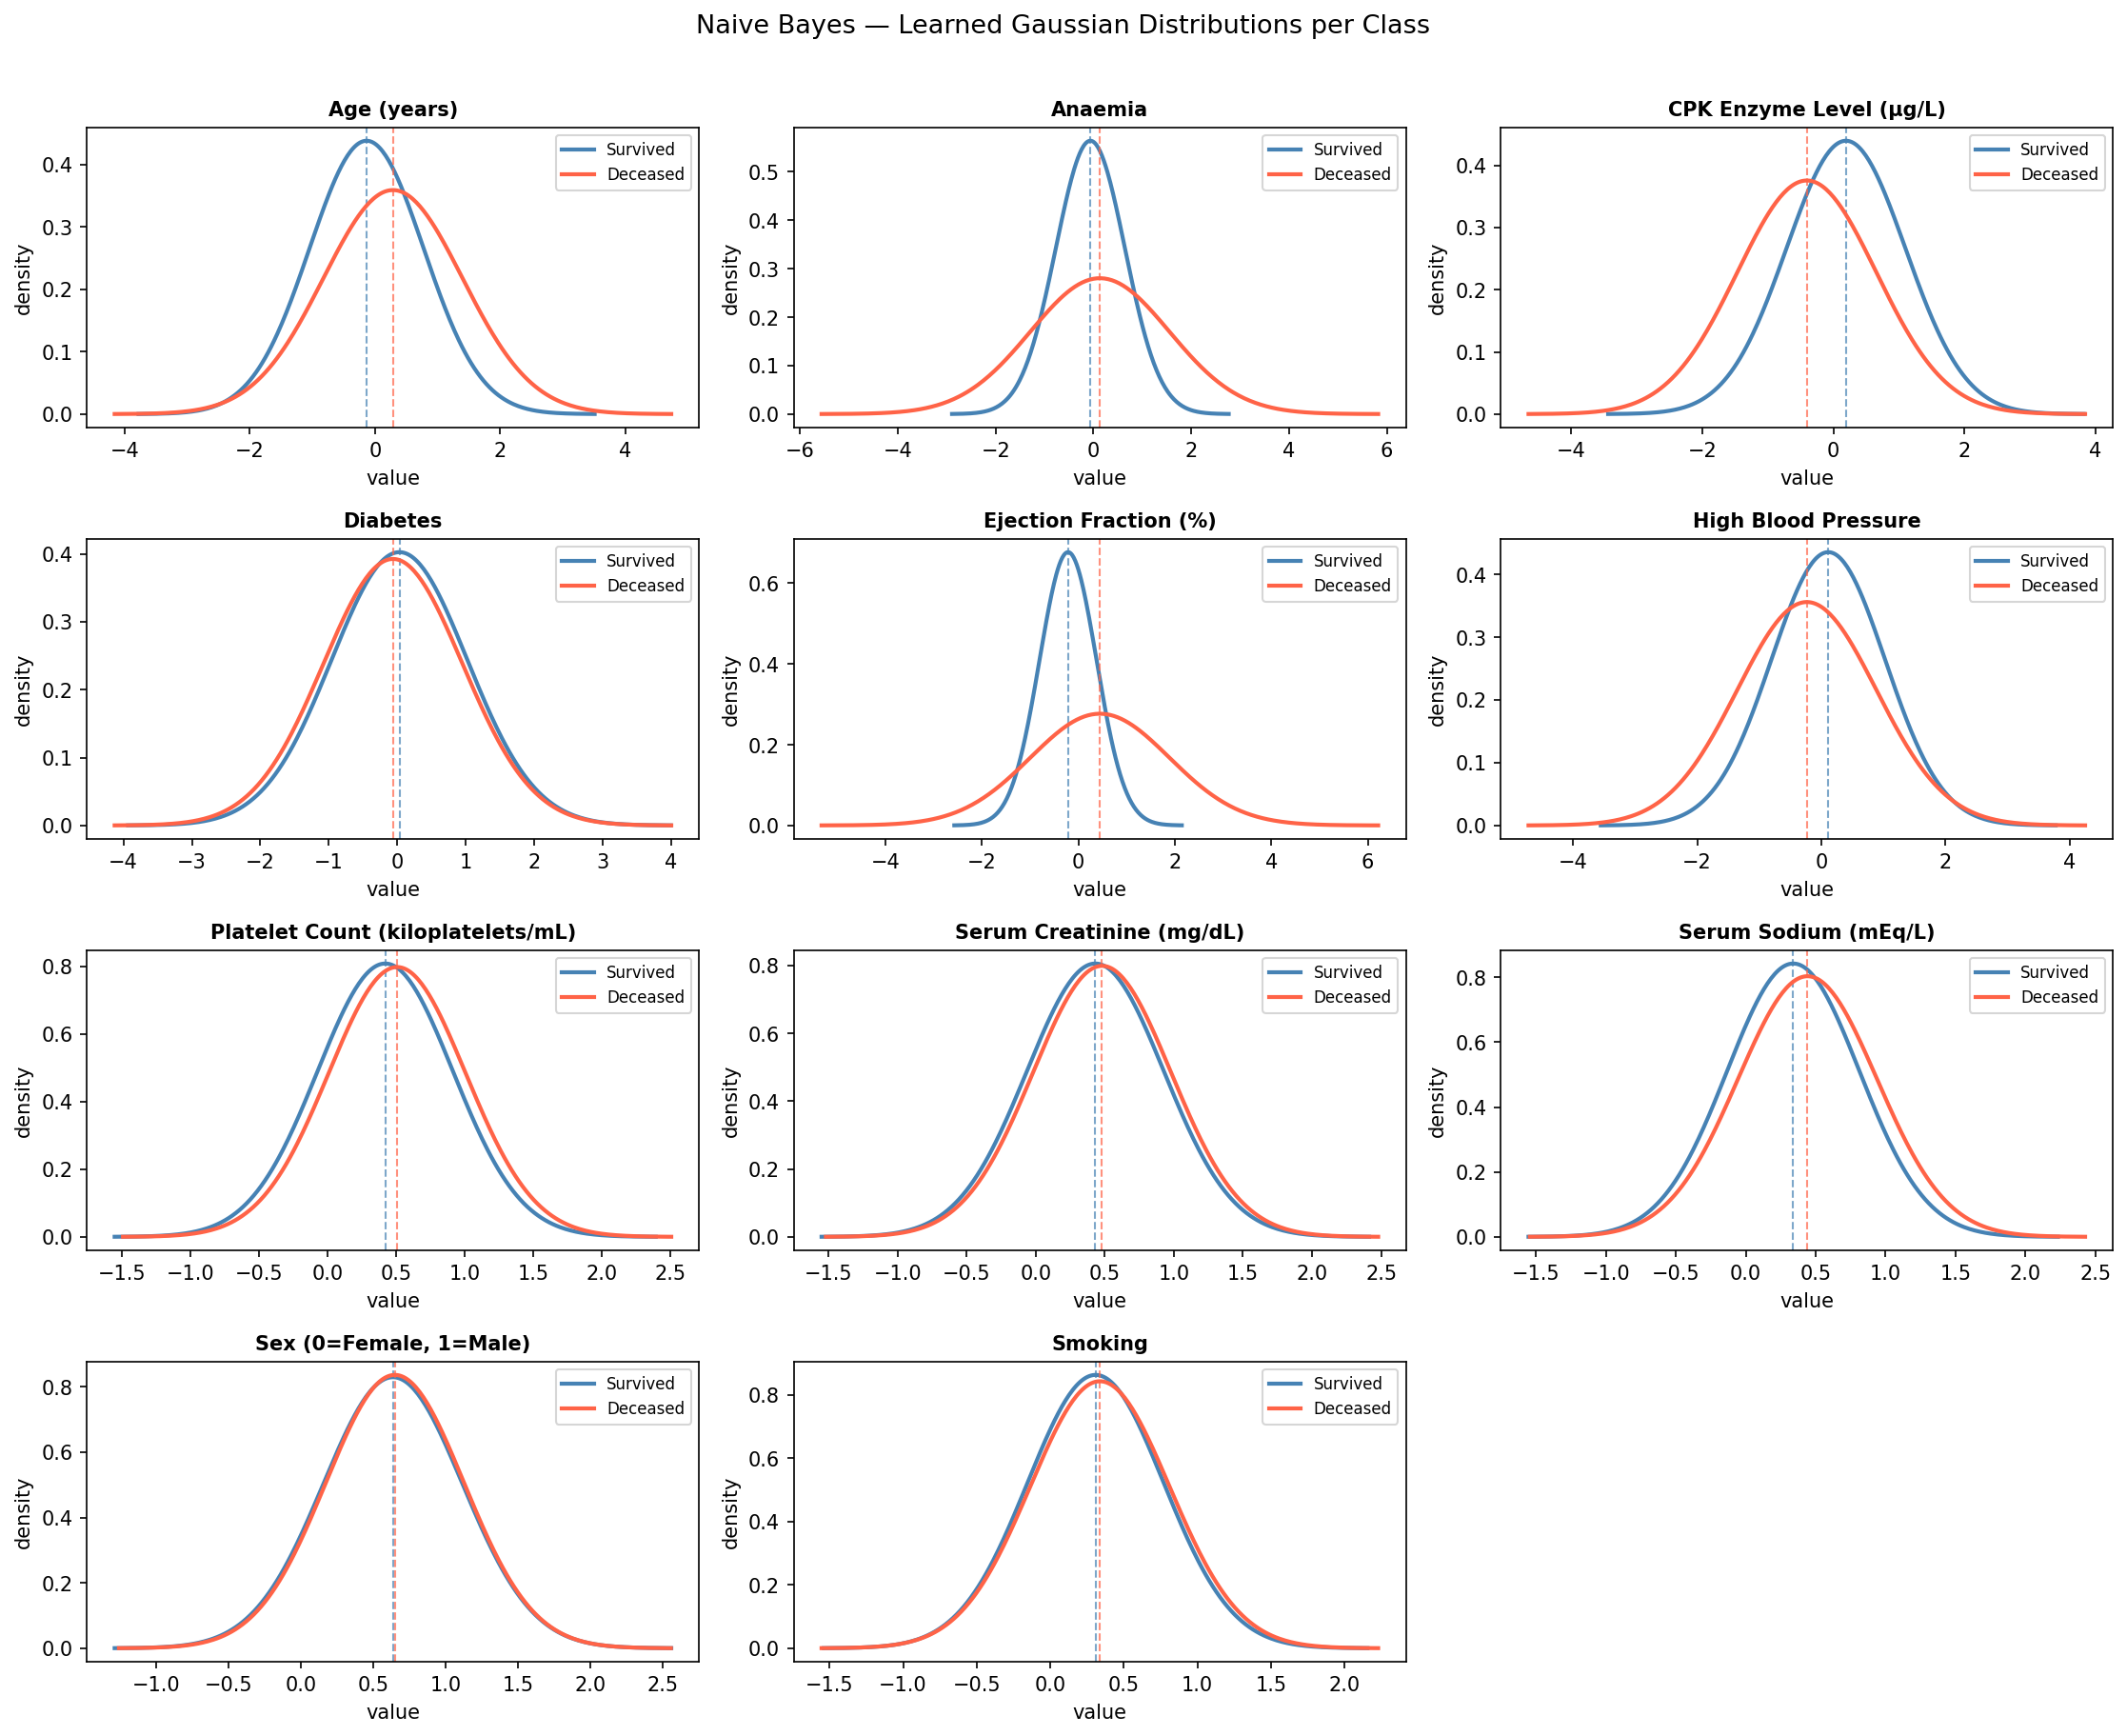

In [4]:
plot_feature_distributions(
    pipeline, READABLE_NAMES, CLASS_NAMES,
    path='../outputs/nb_distributions.png'
)

from IPython.display import Image
Image('../outputs/nb_distributions.png')

### Feature-by-Feature Interpretation

**Ejection Fraction (%)**  
One of the clearest separations in the chart. Survivors have a noticeably higher mean — the heart is pumping more blood per beat. The normal range is ≥ 55%; the Deceased mean typically sits well below 40%, which aligns with established heart failure clinical criteria. Strong discriminator.

**Serum Creatinine (mg/dL)**  
Deceased patients have a higher mean, reflecting kidney stress caused by reduced cardiac output. The real-world distribution of creatinine is right-skewed (a few very high outliers pull the mean up), but GaussianNB forces a symmetric bell curve — a modelling approximation. Despite that, the model correctly identifies the direction and rough magnitude of the difference.

**Serum Sodium (mEq/L)**  
Deceased patients tend toward slightly lower sodium (hyponatraemia is associated with worse heart failure prognosis). The curves overlap substantially, making this a weak but consistent signal. The Decision Tree at depth 3 largely ignored this feature; Naïve Bayes uses it on every prediction because no feature is ever dropped.

**Age (years)**  
The distributions overlap heavily. Deceased patients are slightly older on average, but both classes span a wide age range. Age alone is a weak discriminator in this dataset.

**CPK Enzyme Level (µg/L)**  
High variance in both classes makes this feature noisy. The Gaussians are wide and overlapping; the mean difference is small relative to the spread. It contributes marginal signal.

**Platelet Count (kiloplatelets/mL)**  
Very similar distributions across both classes. Low discriminative value.

**Binary features (Anaemia, Diabetes, High Blood Pressure, Sex, Smoking)**  
These features take only the values 0 and 1, but GaussianNB models them as continuous Gaussians — the plots will show two narrow spikes rather than smooth curves. The model still captures the difference in *proportions* between classes (what fraction of Survived vs. Deceased patients had each condition), but the shape is an artefact of the Gaussian assumption. For a production system, these would be better handled by `BernoulliNB` or by routing feature types to appropriate sub-models within a pipeline.

---
## Key Takeaways

### What the Model Learned

- **Ejection Fraction** and **Serum Creatinine** are again the dominant features — fully consistent with the Decision Tree in notebook 04. Cross-model agreement on the same features is meaningful: it suggests these variables carry genuine predictive signal, not just artefacts of one algorithm's search strategy.
- **Serum Sodium** contributes here even though the Decision Tree mostly ignored it at depth 3. Naïve Bayes uses **all features simultaneously** on every prediction — no feature is ever dropped. Variables the tree never splits on can still meaningfully shift the Bayesian probability estimates.
- **Binary features** contribute, but are imperfectly modelled under the Gaussian assumption. Since they are weak discriminators in this dataset, the approximation error has limited practical impact on classification accuracy — but it is worth flagging in any real-world deployment.

### Naïve Bayes vs Decision Tree — Interpretability Comparison

| Aspect | Decision Tree (notebook 04) | Naïve Bayes (this notebook) |
|---|---|---|
| **What you inspect** | If/else decision rules | Per-class means and standard deviations |
| **How predictions are formed** | Follow one path through binary splits | Multiply Gaussian likelihoods across all features |
| **Features used per prediction** | Only those in the active path (2–3 at depth 3) | All features, every time |
| **Core assumption** | No distributional assumption; greedy split optimisation | Features are Gaussian and conditionally independent within each class |
| **Easiest to explain to a non-ML audience** | ✅ Rules are intuitive to follow | ❌ Multiplying probabilities is less intuitive |
| **Easiest to inspect mathematically** | ❌ Number of rules grows with depth | ✅ Always exactly n_classes × n_features parameters |
| **Handles feature interactions** | Partially — through sequential conditional splits | ❌ Assumes features are fully independent (the naive assumption) |

### Known Limitations

- The **independence assumption** is almost certainly violated. Ejection fraction and serum creatinine are clinically correlated — poor cardiac output reduces kidney perfusion, which elevates creatinine. Treating them as independent means the model's raw probability scores are overconfident and not well-calibrated, even when classification decisions are correct.
- **Binary features are not Gaussian.** In a rigorous pipeline these would be encoded and modelled differently.
- Despite these limitations, Gaussian NB is often **surprisingly competitive** on small datasets like this one (~300 patients), where a more complex model would simply overfit to noise.

### Next Steps

- **Notebook 06** covers KNN — the most instance-based of the three models. Unlike the Decision Tree and Naïve Bayes, KNN has no explicit learned parameters to inspect, so interpretability requires local explanation tools such as SHAP and LIME applied to individual predictions.
- **Notebook 07** brings all three models together for a side-by-side feature importance comparison to see where they agree, where they diverge, and what that divergence tells us about the data and the models.